

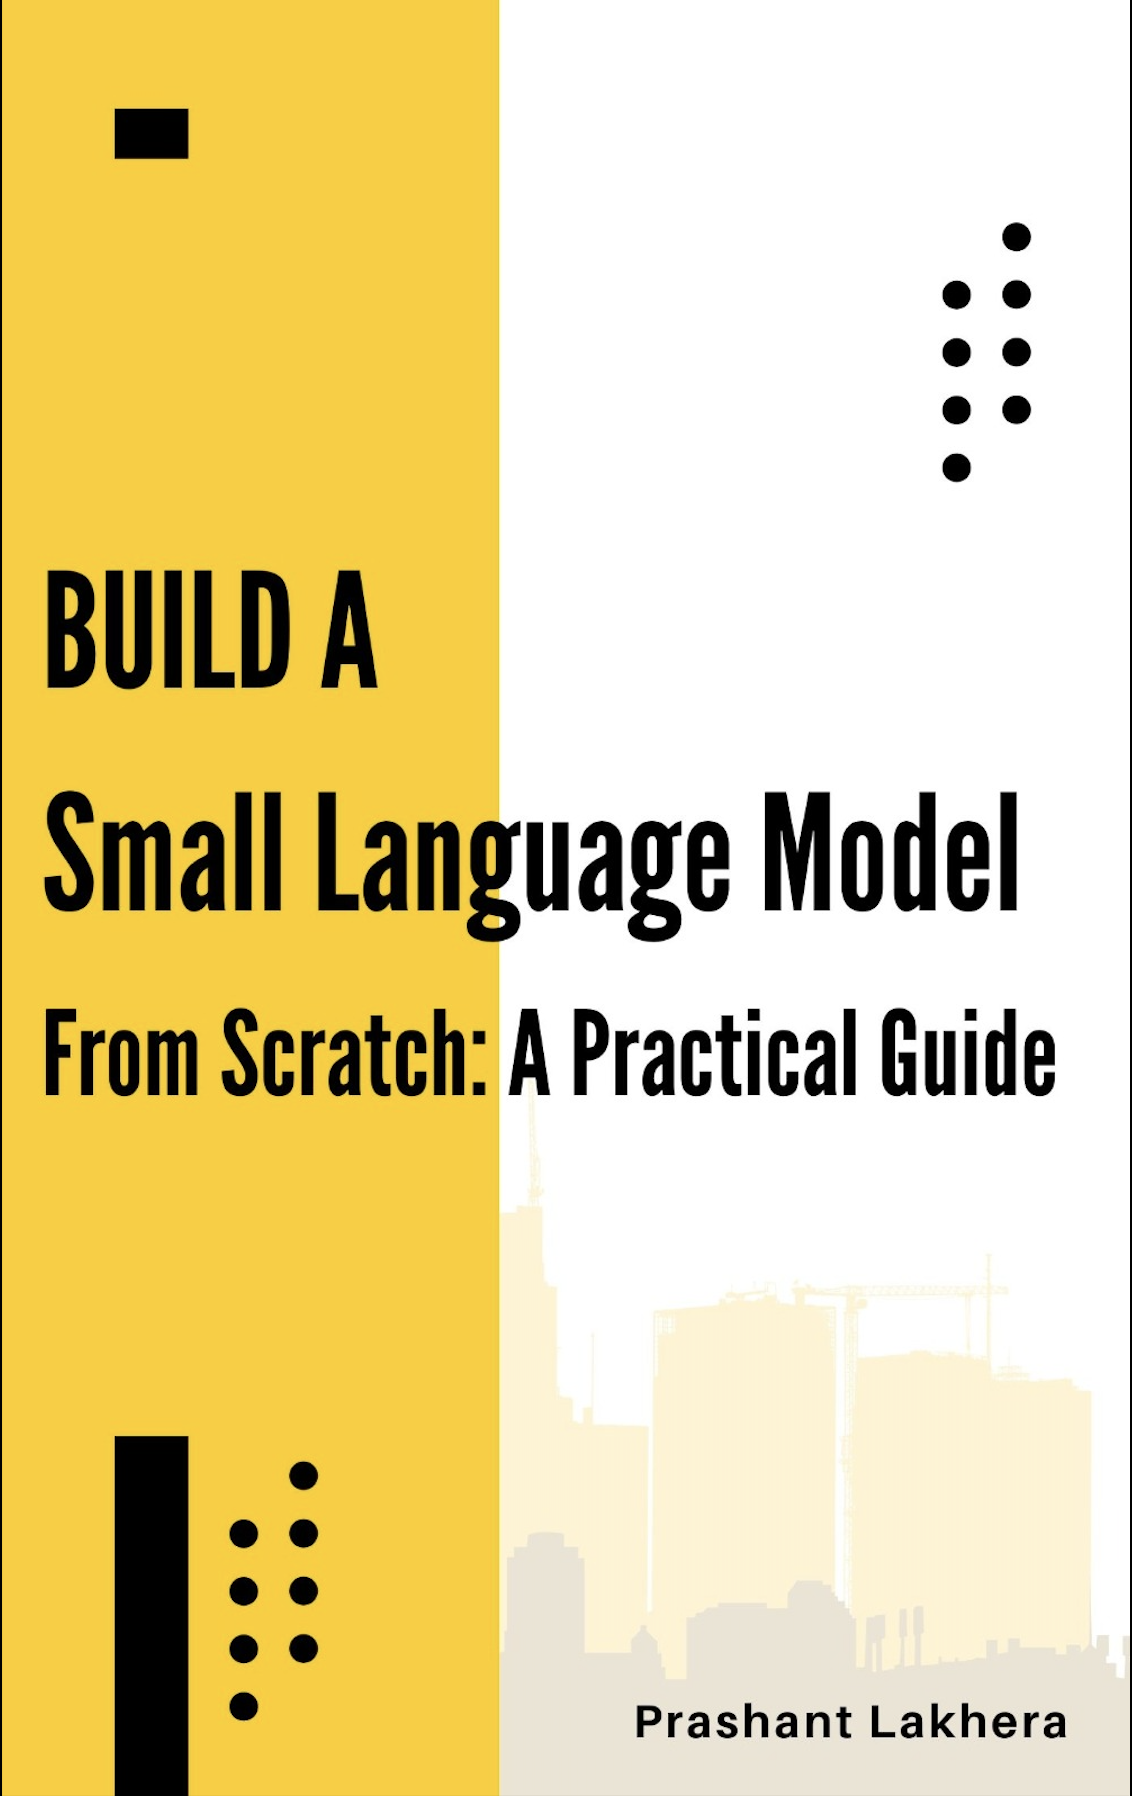

If you want to dive deeper into these concepts, please check out my book.<br>

📚 Here is the book link:<br>
✅ Gumroad: https://plakhera.gumroad.com/l/BuildingASmallLanguageModelfromScratch<br>
✅ Leanpub: https://leanpub.com/buildingasmalllanguagemodelfromscratch


# NOTE:

As you can see, the training stopped at 99,000 iterations because getting access to an A100 GPU is quite difficult these days. But 99k iterations are more than sufficient for this stage of the project.
If you’d like to check out the model, it’s available on Hugging Face: https://huggingface.co/lakhera2023/gemma3-from-scratch

# Building Gemma 3

In [ ]:
import os
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm.auto import tqdm
from datasets import load_dataset
from transformers import AutoTokenizer
from contextlib import nullcontext
from torch.optim.lr_scheduler import LinearLR, SequentialLR, CosineAnnealingLR
import matplotlib.pyplot as plt

# Load Gemma3 tokenizer

In [ ]:
   try:
       tokenizer = AutoTokenizer.from_pretrained("google/gemma-3-1b")
   except:
       # Fallback to Gemma 2 tokenizer (same as Gemini 2.0)
       tokenizer = AutoTokenizer.from_pretrained("google/gemma-2-2b")

tokenizer_config.json:   0%|          | 0.00/46.4k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

# Get vocab size

In [ ]:
vocab_size = tokenizer.vocab_size
print(f"Tokenizer vocab size: {vocab_size}")

Tokenizer vocab size: 256000


# Load dataset

In [ ]:
ds = load_dataset("roneneldan/TinyStories")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00004-2d5a1467fff108(…):   0%|          | 0.00/249M [00:00<?, ?B/s]

data/train-00001-of-00004-5852b56a2bd28f(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/train-00002-of-00004-a26307300439e9(…):   0%|          | 0.00/246M [00:00<?, ?B/s]

data/train-00003-of-00004-d243063613e5a0(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/validation-00000-of-00001-869c898b5(…):   0%|          | 0.00/9.99M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2119719 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/21990 [00:00<?, ? examples/s]

# TOKENIZE THE DATASET

In [ ]:
# Tokenize the dataset using Gemma 3 tokenizer
def process(example):
    """
    Tokenize a single example from the dataset.
    Uses tokenizer.encode() for transformers tokenizer (Gemma 3).
    add_special_tokens=False ensures we don't add BOS/EOS tokens during training.
    """
    ids = tokenizer.encode(example['text'], add_special_tokens=False)
    out = {'ids': ids, 'len': len(ids)}
    return out

# Tokenize the dataset if tokenized files don't exist
if not os.path.exists("train.bin"):
    print("Tokenizing dataset...")
    tokenized = ds.map(
        process,
        remove_columns=['text'],
        desc="tokenizing the splits",
        num_proc=8,  # Use 8 processes for parallel tokenization
    )

    # Concatenate all token IDs into memory-mapped binary files
    for split, dset in tokenized.items():
        arr_len = np.sum(dset['len'], dtype=np.uint64)
        filename = f'{split}.bin'

        # Gemma 3 vocab size is 262,208 > 65536, so we MUST use uint32
        # uint16 can only hold values up to 65535
        dtype = np.uint32 if tokenizer.vocab_size > 65536 else np.uint16
        print(f"Using dtype: {dtype} for vocab_size: {tokenizer.vocab_size}")

        arr = np.memmap(filename, dtype=dtype, mode='w+', shape=(arr_len,))
        total_batches = 1024

        idx = 0
        for batch_idx in tqdm(range(total_batches), desc=f'writing {filename}'):
            batch = dset.shard(num_shards=total_batches, index=batch_idx, contiguous=True).with_format('numpy')
            arr_batch = np.concatenate(batch['ids'])
            arr[idx : idx + len(arr_batch)] = arr_batch
            idx += len(arr_batch)
        arr.flush()
        print(f"Saved {filename} with {arr_len} tokens")

    print("Tokenization complete!")
else:
    print("Tokenized files already exist. Skipping tokenization.")

Tokenized files already exist. Skipping tokenization.


# TRAINING CONFIGURATION & BATCH LOADING

In [ ]:
# Can reduce to 16-24 if OOM, or increase to 48+ if memory allows
batch_size = 32
block_size = 128
device = "cuda" if torch.cuda.is_available() else "cpu"
device_type = 'cuda' if 'cuda' in device else 'cpu'

print(f"Device: {device}")
print(f"Batch size: {batch_size}, Block size: {block_size}")

# Determine dtype for loading tokenized data (must match tokenization dtype)
# Gemma 3 vocab_size = 262,208, so we use uint32
data_dtype = np.uint32 if vocab_size > 65536 else np.uint16
print(f"Using {data_dtype} for loading tokenized data (vocab_size: {vocab_size})")

def get_batch(split):
    """
    Get a batch of training/validation data.

    Args:
        split: 'train' or 'validation'

    Returns:
        x: Input tokens [batch_size, block_size]
        y: Target tokens [batch_size, block_size] (shifted by 1)
    """
    if split == 'train':
        data = np.memmap('train.bin', dtype=data_dtype, mode='r')
    else:
        data = np.memmap('validation.bin', dtype=data_dtype, mode='r')

    # Randomly sample batch_size starting positions
    ix = torch.randint(len(data) - block_size, (batch_size,))

    # Extract sequences and targets (targets are shifted by 1 position)
    x = torch.stack([torch.from_numpy((data[i:i+block_size]).astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy((data[i+1:i+1+block_size]).astype(np.int64)) for i in ix])

    # Move to device with pin_memory for faster GPU transfer
    if device_type == 'cuda':
        x, y = x.pin_memory().to(device, non_blocking=True), y.pin_memory().to(device, non_blocking=True)
    else:
        x, y = x.to(device), y.to(device)

    return x, y

Device: cuda
Batch size: 32, Block size: 128
Using <class 'numpy.uint32'> for loading tokenized data (vocab_size: 256000)


#RoPE (Rotary Position Embeddings) IMPLEMENTATION

In [ ]:
def compute_rope_params(head_dim, theta_base=10_000, context_length=4096, dtype=torch.float32):
    """
    Compute RoPE (Rotary Position Embeddings) parameters.

    Args:
        head_dim: Dimension of each attention head (must be even)
        theta_base: Base frequency for RoPE (10,000 for local, 1,000,000 for global in Gemma 3)
        context_length: Maximum sequence length
        dtype: Data type for computation

    Returns:
        cos: Cosine values for RoPE [context_length, head_dim]
        sin: Sine values for RoPE [context_length, head_dim]
    """
    assert head_dim % 2 == 0, "Embedding dimension must be even"

    # Compute the inverse frequencies
    inv_freq = 1.0 / (theta_base ** (torch.arange(0, head_dim, 2, dtype=dtype)[: (head_dim // 2)].float() / head_dim))

    # Generate position indices
    positions = torch.arange(context_length, dtype=dtype)

    # Compute the angles: positions × inverse_frequencies
    angles = positions[:, None] * inv_freq[None, :]  # Shape: (context_length, head_dim // 2)

    # Expand angles to match the head_dim (duplicate for second half)
    angles = torch.cat([angles, angles], dim=1)  # Shape: (context_length, head_dim)

    # Precompute sine and cosine
    cos = torch.cos(angles)
    sin = torch.sin(angles)

    return cos, sin


def apply_rope(x, cos, sin):
    """
    Apply RoPE (Rotary Position Embeddings) to queries or keys.

    Args:
        x: Input tensor [batch_size, num_heads, seq_len, head_dim]
        cos: Precomputed cosine values [context_length, head_dim]
        sin: Precomputed sine values [context_length, head_dim]

    Returns:
        x_rotated: Rotated tensor with same shape as x
    """
    batch_size, num_heads, seq_len, head_dim = x.shape
    assert head_dim % 2 == 0, "Head dimension must be even"

    # Split x into first half and second half
    x1 = x[..., : head_dim // 2]  # First half
    x2 = x[..., head_dim // 2 :]  # Second half

    # Adjust sin and cos shapes to match x
    cos = cos[:seq_len, :].unsqueeze(0).unsqueeze(0)  # Shape: (1, 1, seq_len, head_dim)
    sin = sin[:seq_len, :].unsqueeze(0).unsqueeze(0)

    # Apply the rotary transformation
    # Rotate by concatenating (-x2, x1) and applying rotation matrix
    rotated = torch.cat((-x2, x1), dim=-1)
    x_rotated = (x * cos) + (rotated * sin)

    # Return in original dtype (it's ok to use lower-precision after applying cos and sin rotation)
    return x_rotated.to(dtype=x.dtype)

#RMSNorm IMPLEMENTATION

In [ ]:
class RMSNorm(nn.Module):
    """
    RMSNorm (Root Mean Square Normalization) - Gemma 3 style.

    Key differences from standard RMSNorm:
    1. Zero-centered weights (initialized to zeros)
    2. Uses (1 + weight) scaling during forward pass
    3. Computes normalization in float32, then converts back

    This matches the HuggingFace Gemma 3 implementation.
    """
    def __init__(self, emb_dim, eps=1e-6, bias=False):
        super().__init__()
        self.eps = eps

        # Gemma 3 stores zero-centered weights and uses (1 + weight) during forward
        self.scale = nn.Parameter(torch.zeros(emb_dim))

        # Optional bias/shift parameter (typically not used in Gemma 3)
        self.shift = nn.Parameter(torch.zeros(emb_dim)) if bias else None

    def forward(self, x):
        """
        Forward pass of RMSNorm.

        Args:
            x: Input tensor [..., emb_dim]

        Returns:
            Normalized tensor with same shape as x
        """
        # Match HF Gemma 3: compute norm in float32, then scale by (1 + w)
        input_dtype = x.dtype
        x_f = x.float()

        # Compute RMS: sqrt(mean(x^2))
        var = x_f.pow(2).mean(dim=-1, keepdim=True)
        x_norm = x_f * torch.rsqrt(var + self.eps)

        # Gemma 3 style: scale by (1 + weight) instead of just weight
        out = x_norm * (1.0 + self.scale.float())

        # Apply optional bias/shift if provided
        if self.shift is not None:
            out = out + self.shift.float()

        return out.to(input_dtype)


# GROUPED QUERY ATTENTION (GQA) IMPLEMENTATION

In [ ]:
# Gemma 3 uses Grouped Query Attention with:
# - Optional QK normalization (controlled by qk_norm parameter)
# - query_pre_attn_scalar for scaling (instead of just head_dim)
# - Supports both local and global attention patterns
# - Uses dual RoPE (different base frequencies for local vs global)

class GroupedQueryAttention(nn.Module):
    """
    Grouped Query Attention (GQA) - Gemma 3 implementation.

    GQA reduces memory by sharing key-value heads across multiple query heads.
    This is more efficient than standard multi-head attention while maintaining
    similar performance.

    Key features:
    - Optional QK normalization (for stability)
    - Configurable query scaling (query_pre_attn_scalar)
    - Supports dual RoPE (local and global with different frequencies)
    """
    def __init__(
        self,
        d_in,
        num_heads,
        num_kv_groups,
        head_dim=None,
        qk_norm=False,  # Optional QK normalization (Gemma 3 uses this)
        query_pre_attn_scalar=None,  # Custom scaling (Gemma 3 uses 256 for 270M model)
        dtype=None
    ):
        super().__init__()
        assert num_heads % num_kv_groups == 0, "num_heads must be divisible by num_kv_groups"

        self.num_heads = num_heads
        self.num_kv_groups = num_kv_groups
        self.group_size = num_heads // num_kv_groups  # How many query heads share each KV head

        if head_dim is None:
            assert d_in % num_heads == 0, "`d_in` must be divisible by `num_heads` if `head_dim` is not set"
            head_dim = d_in // num_heads

        self.head_dim = head_dim
        self.d_out = num_heads * head_dim

        # Projections: Q has num_heads, K and V have num_kv_groups (fewer)
        self.W_query = nn.Linear(d_in, self.d_out, bias=False, dtype=dtype)
        self.W_key = nn.Linear(d_in, num_kv_groups * head_dim, bias=False, dtype=dtype)
        self.W_value = nn.Linear(d_in, num_kv_groups * head_dim, bias=False, dtype=dtype)
        self.out_proj = nn.Linear(self.d_out, d_in, bias=False, dtype=dtype)

        # Optional QK normalization (Gemma 3 uses this for stability)
        if qk_norm:
            self.q_norm = RMSNorm(head_dim, eps=1e-6)
            self.k_norm = RMSNorm(head_dim, eps=1e-6)
        else:
            self.q_norm = self.k_norm = None

        # Query scaling: Gemma 3 uses query_pre_attn_scalar instead of head_dim
        # This allows custom scaling independent of head dimension
        if query_pre_attn_scalar is not None:
            self.scaling = (query_pre_attn_scalar) ** -0.5
        else:
            self.scaling = (head_dim) ** -0.5

    def forward(self, x, mask, cos, sin):
        """
        Forward pass of Grouped Query Attention.

        Args:
            x: Input tensor [batch_size, num_tokens, d_in]
            mask: Attention mask [seq_len, seq_len] or [batch_size, num_heads, seq_len, seq_len]
            cos: Precomputed cosine values for RoPE [context_length, head_dim]
            sin: Precomputed sine values for RoPE [context_length, head_dim]

        Returns:
            Output tensor [batch_size, num_tokens, d_in]
        """
        b, num_tokens, _ = x.shape

        # Apply projections
        queries = self.W_query(x)  # (b, num_tokens, num_heads * head_dim)
        keys = self.W_key(x)       # (b, num_tokens, num_kv_groups * head_dim)
        values = self.W_value(x)   # (b, num_tokens, num_kv_groups * head_dim)

        # Reshape to separate heads
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        keys = keys.view(b, num_tokens, self.num_kv_groups, self.head_dim).transpose(1, 2)
        values = values.view(b, num_tokens, self.num_kv_groups, self.head_dim).transpose(1, 2)

        # Optional QK normalization (Gemma 3 feature for training stability)
        if self.q_norm:
            queries = self.q_norm(queries)
        if self.k_norm:
            keys = self.k_norm(keys)

        # Apply RoPE (Rotary Position Embeddings)
        # Note: cos and sin will be different for local vs global attention
        queries = apply_rope(queries, cos, sin)
        keys = apply_rope(keys, cos, sin)

        # Expand K and V to match number of query heads (GQA mechanism)
        # Each KV head is shared by group_size query heads
        keys = keys.repeat_interleave(self.group_size, dim=1)
        values = values.repeat_interleave(self.group_size, dim=1)

        # Scale queries (Gemma 3 uses custom query_pre_attn_scalar)
        queries = queries * self.scaling

        # Scaled dot-product attention
        attn_scores = queries @ keys.transpose(2, 3)  # (b, num_heads, seq_len, seq_len)
        attn_scores = attn_scores.masked_fill(mask, -torch.inf)
        attn_weights = torch.softmax(attn_scores, dim=-1)

        # Apply attention weights to values
        context = (attn_weights @ values).transpose(1, 2).reshape(b, num_tokens, self.d_out)

        # Final output projection
        return self.out_proj(context)

# FEEDFORWARD NETWORK IMPLEMENTATION

In [ ]:
# Gemma 3 uses GeLU-based FeedForward
# Architecture: GeLU(fc1(x)) * fc2(x) -> fc3
# Both fc1 and fc2 take the same input x (parallel projections)

class FeedForward(nn.Module):
    """
    FeedForward Network - Gemma 3 implementation.

    Note: Gemma 3 uses GeLU activation.
    - SwiGLU: gate = SiLU(fc1(x)), up = fc2(x), output = fc3(gate * up)
    - Gemma 3: output = fc3(GeLU(fc1(x)) * fc2(x))

    Both fc1 and fc2 receive the same input x in parallel.
    """
    def __init__(self, cfg):
        """
        Args:
            cfg: Configuration dictionary with:
                - emb_dim: Embedding dimension (input/output)
                - hidden_dim: Hidden dimension (intermediate)
                - dtype: Data type for layers
        """
        super().__init__()
        # Two parallel projections from emb_dim to hidden_dim
        self.fc1 = nn.Linear(cfg["emb_dim"], cfg["hidden_dim"], dtype=cfg["dtype"], bias=False)
        self.fc2 = nn.Linear(cfg["emb_dim"], cfg["hidden_dim"], dtype=cfg["dtype"], bias=False)
        # Output projection from hidden_dim back to emb_dim
        self.fc3 = nn.Linear(cfg["hidden_dim"], cfg["emb_dim"], dtype=cfg["dtype"], bias=False)

    def forward(self, x):
        """
        Forward pass: GeLU(fc1(x)) * fc2(x) -> fc3

        Args:
            x: Input tensor [batch_size, seq_len, emb_dim]

        Returns:
            Output tensor [batch_size, seq_len, emb_dim]
        """
        # Both projections receive the same input
        x_fc1 = self.fc1(x)  # Projection 1
        x_fc2 = self.fc2(x)  # Projection 2

        # GeLU activation on fc1, then element-wise multiply with fc2
        # approximate="tanh" is faster and numerically stable
        x = nn.functional.gelu(x_fc1, approximate="tanh") * x_fc2

        # Final projection back to emb_dim
        return self.fc3(x)

# TRANSFORMER BLOCK IMPLEMENTATION

In [ ]:
# Gemma 3 TransformerBlock supports hybrid attention:
# - Local attention (sliding window) with local RoPE and mask
# - Global attention (full context) with global RoPE and mask
# - Uses 4 normalization layers (pre/post for both attention and feedforward)
# - Pre-norm architecture with residual connections

class TransformerBlock(nn.Module):
    """
    Transformer Block - Gemma 3 implementation with hybrid attention support.

    Key features:
    - Supports both local (sliding window) and global (full context) attention
    - Uses dual RoPE (different frequencies for local vs global)
    - Pre-norm architecture with 4 normalization layers
    - Residual connections for both attention and feedforward
    """
    def __init__(self, cfg: dict, attn_type: str):
        """
        Args:
            cfg: Configuration dictionary with model parameters
            attn_type: "sliding_attention" (local) or "full_attention" (global)
        """
        super().__init__()
        self.attn_type = attn_type  # Determines which attention pattern to use

        # Grouped Query Attention
        self.att = GroupedQueryAttention(
            d_in=cfg["emb_dim"],
            num_heads=cfg["n_heads"],
            num_kv_groups=cfg["n_kv_groups"],
            head_dim=cfg["head_dim"],
            qk_norm=cfg["qk_norm"],
            query_pre_attn_scalar=cfg["query_pre_attn_scalar"],
            dtype=cfg["dtype"],
        )

        # FeedForward network (GeLU-based)
        self.ff = FeedForward(cfg)

        # Gemma 3 uses 4 normalization layers (not just 2)
        # This provides better gradient flow and training stability
        self.input_layernorm = RMSNorm(cfg["emb_dim"], eps=1e-6)
        self.post_attention_layernorm = RMSNorm(cfg["emb_dim"], eps=1e-6)
        self.pre_feedforward_layernorm = RMSNorm(cfg["emb_dim"], eps=1e-6)
        self.post_feedforward_layernorm = RMSNorm(cfg["emb_dim"], eps=1e-6)

    def forward(
        self,
        x,
        mask_global,
        mask_local,
        cos_global,
        sin_global,
        cos_local,
        sin_local,
    ):
        """
        Forward pass of Transformer Block.

        Args:
            x: Input tensor [batch_size, seq_len, emb_dim]
            mask_global: Global attention mask (for full attention layers)
            mask_local: Local attention mask (for sliding window layers)
            cos_global: Global RoPE cosine values
            sin_global: Global RoPE sine values
            cos_local: Local RoPE cosine values
            sin_local: Local RoPE sine values

        Returns:
            Output tensor [batch_size, seq_len, emb_dim]
        """
        # ============================================================
        # ATTENTION BLOCK (with residual connection)
        # ============================================================
        shortcut = x  # Save for residual connection

        # Pre-norm: normalize before attention
        x = self.input_layernorm(x)

        # Select appropriate mask and RoPE based on attention type
        if self.attn_type == "sliding_attention":
            # Local attention: sliding window pattern
            attn_mask = mask_local
            cos = cos_local
            sin = sin_local
        else:
            # Global attention: full context pattern
            attn_mask = mask_global
            cos = cos_global
            sin = sin_global

        # Apply attention
        x_attn = self.att(x, attn_mask, cos, sin)

        # Post-attention normalization (before residual)
        x_attn = self.post_attention_layernorm(x_attn)

        # Residual connection
        x = shortcut + x_attn

        # ============================================================
        # FEEDFORWARD BLOCK (with residual connection)
        # ============================================================
        shortcut = x  # Save for residual connection

        # Pre-norm: normalize before feedforward
        x_ffn = self.pre_feedforward_layernorm(x)

        # Apply feedforward
        x_ffn = self.ff(x_ffn)

        # Post-feedforward normalization (before residual)
        x_ffn = self.post_feedforward_layernorm(x_ffn)

        # Residual connection
        x = shortcut + x_ffn

        return x

# GEMMA 3 MODEL IMPLEMENTATION

In [ ]:
# Main model class that combines all components:
# - Token embeddings
# - Hybrid attention transformer blocks (local/global)
# - Dual RoPE (local: 10k, global: 1M base frequencies)
# - Dual masks (sliding window and full context)
# - Output head for next-token prediction

class Gemma3Model(nn.Module):
    """
    Gemma 3 Model - Complete implementation with hybrid attention.

    Key features:
    - Hybrid local/global attention (5:1 ratio)
    - Dual RoPE configuration (10k local, 1M global)
    - Sliding window attention for memory efficiency
    - Supports up to 128K context length
    """
    def __init__(self, cfg):
        """
        Args:
            cfg: Configuration dictionary with:
                - vocab_size: Vocabulary size
                - emb_dim: Embedding dimension
                - n_heads: Number of attention heads
                - n_kv_groups: Number of KV groups (for GQA)
                - n_layers: Number of transformer layers
                - head_dim: Dimension of each attention head
                - hidden_dim: Feedforward hidden dimension
                - context_length: Maximum context length
                - layer_types: List of "sliding_attention" or "full_attention" for each layer
                - rope_local_base: RoPE base frequency for local attention (10,000)
                - rope_base: RoPE base frequency for global attention (1,000,000)
                - sliding_window: Sliding window size for local attention
                - qk_norm: Whether to use QK normalization
                - query_pre_attn_scalar: Query scaling factor
                - dtype: Data type for model
        """
        super().__init__()

        # Validate layer_types configuration
        assert cfg["layer_types"] is not None, "layer_types must be specified"
        assert len(cfg["layer_types"]) == cfg["n_layers"], \
            f"layer_types length ({len(cfg['layer_types'])}) must match n_layers ({cfg['n_layers']})"

        # Token embeddings
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"], dtype=cfg["dtype"])

        # Transformer blocks with hybrid attention
        # Each block is configured as either "sliding_attention" (local) or "full_attention" (global)
        self.blocks = nn.ModuleList([
            TransformerBlock(cfg, attn_type) for attn_type in cfg["layer_types"]
        ])

        # Final normalization and output head
        self.final_norm = RMSNorm(cfg["emb_dim"], eps=1e-6)
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False, dtype=cfg["dtype"])

        # Store configuration
        self.cfg = cfg

        # ============================================================
        # DUAL RoPE CONFIGURATION
        # ============================================================
        # Compute RoPE parameters for both local and global attention
        # Local: theta_base = 10,000 (for sliding window attention)
        # Global: theta_base = 1,000,000 (for full context attention)

        cos_local, sin_local = compute_rope_params(
            head_dim=cfg["head_dim"],
            theta_base=cfg["rope_local_base"],  # 10,000 for local
            context_length=cfg["context_length"],
            dtype=torch.float32,
        )

        cos_global, sin_global = compute_rope_params(
            head_dim=cfg["head_dim"],
            theta_base=cfg["rope_base"],  # 1,000,000 for global
            context_length=cfg["context_length"],
            dtype=torch.float32,
        )

        # Register as buffers (not trainable parameters)
        self.register_buffer("cos_local", cos_local, persistent=False)
        self.register_buffer("sin_local", sin_local, persistent=False)
        self.register_buffer("cos_global", cos_global, persistent=False)
        self.register_buffer("sin_global", sin_global, persistent=False)

    def _create_masks(self, seq_len, device):
        """
        Create attention masks for both local and global attention.

        Args:
            seq_len: Sequence length
            device: Device to create masks on

        Returns:
            mask_global: Causal mask for global attention (upper triangular)
            mask_local: Sliding window mask for local attention (causal + far-past)
        """
        ones = torch.ones((seq_len, seq_len), dtype=torch.bool, device=device)

        # mask_global: Standard causal mask (future tokens are masked)
        #     j:  0 1 2 3 4 5 6 7
        #  i
        #     0:  0 1 1 1 1 1 1 1
        #     1:  0 0 1 1 1 1 1 1
        #     2:  0 0 0 1 1 1 1 1
        #     ...
        mask_global = torch.triu(ones, diagonal=1)

        # far_past: Mask tokens that are too far back (beyond sliding window)
        # where sliding_window = 512 (for 270M model) or 1024 (for larger models)
        #     j:  0 1 2 3 4 5 6 7
        #  i
        #     0:  0 0 0 0 0 0 0 0
        #     1:  0 0 0 0 0 0 0 0
        #     4:  1 0 0 0 0 0 0 0  (if sliding_window=4, position 0 is too far)
        #     ...
        far_past = torch.triu(ones, diagonal=self.cfg["sliding_window"]).T

        # mask_local: Sliding window mask = causal mask OR far-past mask
        # This creates a "window" where each token can only attend to:
        # - Future tokens (masked by causal mask)
        # - Nearby past tokens within sliding_window
        # - Far past tokens are masked out
        mask_local = mask_global | far_past

        return mask_global, mask_local

    def forward(self, input_ids, targets=None):
        """
        Forward pass of Gemma 3 model.

        Args:
            input_ids: Input token IDs [batch_size, seq_len]
            targets: Target token IDs for loss computation [batch_size, seq_len]

        Returns:
            logits: Output logits [batch_size, seq_len, vocab_size]
            loss: Cross-entropy loss (if targets provided)
        """
        b, seq_len = input_ids.shape

        # Token embeddings with scaling (Gemma 3 style)
        x = self.tok_emb(input_ids) * (self.cfg["emb_dim"] ** 0.5)

        # Create masks for both local and global attention
        mask_global, mask_local = self._create_masks(seq_len, x.device)

        # Pass through transformer blocks
        # Each block selects appropriate mask and RoPE based on its attn_type
        for block in self.blocks:
            x = block(
                x,
                mask_global=mask_global,
                mask_local=mask_local,
                cos_global=self.cos_global,
                sin_global=self.sin_global,
                cos_local=self.cos_local,
                sin_local=self.sin_local,
            )

        # Final normalization and output projection
        x = self.final_norm(x)
        logits = self.out_head(x.to(self.cfg["dtype"]))

        # Compute loss if targets provided
        loss = None
        if targets is not None:
            loss = F.cross_entropy(
                logits.reshape(-1, logits.size(-1)),
                targets.reshape(-1)
            )

        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        """
        Generate text using the model.

        Args:
            idx: Initial token IDs [batch_size, seq_len]
            max_new_tokens: Maximum number of tokens to generate
            temperature: Sampling temperature (higher = more random)
            top_k: Top-k sampling (only consider top k tokens)

        Returns:
            Generated token IDs [batch_size, seq_len + max_new_tokens]
        """
        for _ in range(max_new_tokens):
            # Truncate to context_length if needed
            ctx_len = self.cfg["context_length"]
            idx_cond = idx if idx.size(1) <= ctx_len else idx[:, -ctx_len:]

            # Forward pass
            logits, _ = self(idx_cond)  # targets=None by default

            # Get logits for last token and apply temperature
            logits = logits[:, -1, :] / temperature

            # Apply top-k filtering if specified
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = float("-inf")

            # Sample next token
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)

            # Append to sequence
            idx = torch.cat((idx, idx_next), dim=1)

        return idx

# MODEL CONFIGURATION

In [ ]:
GEMMA3_CONFIG = {
    # Vocabulary
    "vocab_size": vocab_size,  # 262,208 for Gemma 3 (set from tokenizer)

    # Model dimensions
    "emb_dim": 640,              # Embedding dimension (was d_model in Qwen3)
    "n_heads": 4,                # Number of attention heads
    "head_dim": 256,              # Dimension per head (emb_dim // n_heads = 160, but Gemma uses 256)
    "n_kv_groups": 1,            # KV groups for GQA (1 = standard attention)
    "n_layers": 18,               # Number of transformer layers
    "hidden_dim": 2048,           # Feedforward hidden dimension (was d_ff in Qwen3)

    # Context length
    "context_length": 32_768,     # Maximum context length (32K for training, can extend to 128K)

    # Hybrid attention configuration (5:1 local/global ratio)
    # Pattern: 5 sliding_attention, 1 full_attention, repeat
    "layer_types": [
        "sliding_attention",  # Layer 0: Local
        "sliding_attention",  # Layer 1: Local
        "sliding_attention",  # Layer 2: Local
        "sliding_attention",  # Layer 3: Local
        "sliding_attention",  # Layer 4: Local
        "full_attention",      # Layer 5: Global
        "sliding_attention",  # Layer 6: Local
        "sliding_attention",  # Layer 7: Local
        "sliding_attention",  # Layer 8: Local
        "sliding_attention",  # Layer 9: Local
        "sliding_attention",  # Layer 10: Local
        "full_attention",      # Layer 11: Global
        "sliding_attention",  # Layer 12: Local
        "sliding_attention",  # Layer 13: Local
        "sliding_attention",  # Layer 14: Local
        "sliding_attention",  # Layer 15: Local
        "sliding_attention",  # Layer 16: Local
        "full_attention",      # Layer 17: Global
    ],

    # RoPE configuration (dual: local and global)
    "rope_local_base": 10_000.0,      # Base frequency for local attention layers
    "rope_base": 1_000_000.0,         # Base frequency for global attention layers

    # Sliding window configuration
    "sliding_window": 512,             # Sliding window size for local attention (512 for 270M-400M models)

    # Attention features
    "qk_norm": True,                   # Use QK normalization for stability
    "query_pre_attn_scalar": 256,      # Query scaling factor (instead of head_dim)

    # Data type
    "dtype": torch.bfloat16,         # Use bfloat16 for memory efficiency
}

# Validate configuration
assert len(GEMMA3_CONFIG["layer_types"]) == GEMMA3_CONFIG["n_layers"], \
    f"layer_types length ({len(GEMMA3_CONFIG['layer_types'])}) must match n_layers ({GEMMA3_CONFIG['n_layers']})"

print("=" * 70)
print("GEMMA 3 MODEL CONFIGURATION")
print("=" * 70)
print(f"Model Size: ~400M parameters (estimated)")
print(f"Vocab Size: {GEMMA3_CONFIG['vocab_size']}")
print(f"Embedding Dim: {GEMMA3_CONFIG['emb_dim']}")
print(f"Layers: {GEMMA3_CONFIG['n_layers']}")
print(f"Attention Heads: {GEMMA3_CONFIG['n_heads']}")
print(f"Head Dim: {GEMMA3_CONFIG['head_dim']}")
print(f"Context Length: {GEMMA3_CONFIG['context_length']:,}")
print(f"Sliding Window: {GEMMA3_CONFIG['sliding_window']}")
print(f"Local Layers: {sum(1 for t in GEMMA3_CONFIG['layer_types'] if t == 'sliding_attention')}")
print(f"Global Layers: {sum(1 for t in GEMMA3_CONFIG['layer_types'] if t == 'full_attention')}")
print(f"RoPE Local Base: {GEMMA3_CONFIG['rope_local_base']:,}")
print(f"RoPE Global Base: {GEMMA3_CONFIG['rope_base']:,}")
print("=" * 70)

# Initialize model
torch.manual_seed(123)
model = Gemma3Model(GEMMA3_CONFIG)

# Calculate approximate parameter count
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

total_params = count_parameters(model)
print(f"\nTotal trainable parameters: {total_params:,} (~{total_params/1e6:.1f}M)")
print(f"Estimated memory usage: ~25-30GB (with batch_size={batch_size}, block_size={block_size})")
print("=" * 70)

GEMMA 3 MODEL CONFIGURATION
Model Size: ~400M parameters (estimated)
Vocab Size: 256000
Embedding Dim: 640
Layers: 18
Attention Heads: 4
Head Dim: 256
Context Length: 32,768
Sliding Window: 512
Local Layers: 15
Global Layers: 3
RoPE Local Base: 10,000.0
RoPE Global Base: 1,000,000.0

Total trainable parameters: 428,006,016 (~428.0M)
Estimated memory usage: ~25-30GB (with batch_size=32, block_size=128)


#LOSS ESTIMATION FUNCTION

In [ ]:
def estimate_loss(model, eval_iters=200):
    """
    Estimate average loss on training and validation sets.

    Args:
        model: Gemma3Model instance
        eval_iters: Number of batches to evaluate on

    Returns:
        Dictionary with 'train' and 'val' loss values
    """
    out = {}
    model.eval()  # Set model to evaluation mode

    with torch.no_grad():  # Disable gradient computation for efficiency
        for split in ['train', 'val']:
            losses = torch.zeros(eval_iters)
            for k in range(eval_iters):
                X, Y = get_batch(split)
                # Forward pass (no need for mixed precision in eval)
                logits, loss = model(X, Y)
                losses[k] = loss.item()
            out[split] = losses.mean()

    model.train()  # Set model back to training mode
    return out

# TRAINING CONFIGURATION

In [ ]:
# Training hyperparameters optimized for Gemma 3
# These values are safe for A100 40GB with ~428M parameter model

# Learning rate schedule
learning_rate = 1e-4          # Initial learning rate
max_iters = 150000             # Total training iterations
warmup_steps = 1000            # Linear warmup steps
min_lr = 5e-4                  # Minimum learning rate (after decay)
eval_iters = 500               # Evaluate every N iterations

# Gradient accumulation (simulates larger batch size without more memory)
gradient_accumulation_steps = 32  # Effective batch size = 32 * 32 = 1024

# Mixed precision training
# bfloat16 is preferred for A100 (better numerical stability than float16)
dtype = 'bfloat16' if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else 'float16'
ptdtype = {'float32': torch.float32, 'bfloat16': torch.bfloat16, 'float16': torch.float16}[dtype]

# Autocast context for mixed precision training
ctx = nullcontext() if device_type == 'cpu' else torch.amp.autocast(device_type=device_type, dtype=ptdtype)

# Set default device and seed
torch.set_default_device(device)
torch.manual_seed(42)

print("\n" + "=" * 70)
print("TRAINING CONFIGURATION")
print("=" * 70)
print(f"Learning Rate: {learning_rate}")
print(f"Max Iterations: {max_iters:,}")
print(f"Warmup Steps: {warmup_steps:,}")
print(f"Min Learning Rate: {min_lr}")
print(f"Eval Frequency: Every {eval_iters} iterations")
print(f"Batch Size: {batch_size}")
print(f"Block Size: {block_size}")
print(f"Gradient Accumulation Steps: {gradient_accumulation_steps}")
print(f"Effective Batch Size: {batch_size * gradient_accumulation_steps}")
print(f"Mixed Precision: {dtype}")
print(f"Device: {device}")
print("=" * 70)

# ============================================================================
# OPTIMIZER AND SCHEDULER SETUP
# ============================================================================
# AdamW optimizer with weight decay for regularization
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    betas=(0.9, 0.95),      # Beta1=0.9, Beta2=0.95 (standard for LLMs)
    weight_decay=0.1,       # L2 regularization
    eps=1e-9                 # Epsilon for numerical stability
)

# Learning rate scheduler: Linear warmup + Cosine annealing
scheduler_warmup = LinearLR(optimizer, total_iters=warmup_steps)
scheduler_decay = CosineAnnealingLR(
    optimizer,
    T_max=max_iters - warmup_steps,  # Cosine decay period
    eta_min=min_lr                    # Minimum learning rate
)
scheduler = SequentialLR(
    optimizer,
    schedulers=[scheduler_warmup, scheduler_decay],
    milestones=[warmup_steps]  # Switch from warmup to decay at this step
)

# Gradient scaler for float16 (not needed for bfloat16, but enabled for compatibility)
# Use new API to avoid deprecation warning
if dtype == 'float16' and device_type == 'cuda':
    scaler = torch.amp.GradScaler('cuda', enabled=True)
else:
    scaler = torch.amp.GradScaler('cuda', enabled=False)  # Disabled for bfloat16

print("\nOptimizer and scheduler configured:")
print(f"  Optimizer: AdamW (betas=(0.9, 0.95), weight_decay=0.1)")
print(f"  Scheduler: Linear warmup ({warmup_steps} steps) → Cosine decay")
print(f"  Grad Scaler: {'Enabled' if dtype == 'float16' else 'Disabled (bfloat16)'}")
print("=" * 70)


TRAINING CONFIGURATION
Learning Rate: 0.0001
Max Iterations: 150,000
Warmup Steps: 1,000
Min Learning Rate: 0.0005
Eval Frequency: Every 500 iterations
Batch Size: 32
Block Size: 128
Gradient Accumulation Steps: 32
Effective Batch Size: 1024
Mixed Precision: bfloat16
Device: cuda

Optimizer and scheduler configured:
  Optimizer: AdamW (betas=(0.9, 0.95), weight_decay=0.1)
  Scheduler: Linear warmup (1000 steps) → Cosine decay
  Grad Scaler: Disabled (bfloat16)


# TRAINING LOOP

In [ ]:
# Main training loop for Gemma 3
# Includes gradient accumulation, mixed precision, and checkpoint saving

# Initialize training tracking variables
best_val_loss = float('inf')
best_model_params_path = "gemma3_model.pt"
train_loss_list, validation_loss_list = [], []

# Move model to device
model = model.to(device)
print(f"\nModel moved to {device}")
print("Starting training...")
print("=" * 70)

# Training loop
for epoch in tqdm(range(max_iters), desc="Training"):
    # Evaluate model periodically
    if epoch % eval_iters == 0 and epoch != 0:
        losses = estimate_loss(model, eval_iters=eval_iters)
        print(f"\nEpoch {epoch}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")
        print(f"Current learning rate: {optimizer.param_groups[0]['lr']:.6f}")

        # Store losses for plotting
        train_loss_list.append(losses['train'])
        validation_loss_list.append(losses['val'])

        # Save best model based on validation loss
        if losses['val'] < best_val_loss:
            best_val_loss = losses['val']
            torch.save(model.state_dict(), best_model_params_path)
            print(f"✓ New best model saved! (val loss: {best_val_loss:.4f})")

    # Get training batch
    X, y = get_batch("train")
    # Note: get_batch already moves to device, but being explicit here
    X, y = X.to(device), y.to(device)

    # Forward pass with mixed precision
    with ctx:  # Autocast context for mixed precision training
        logits, loss = model(X, y)
        # Scale loss by gradient accumulation steps
        # This ensures the effective gradient is correct when accumulated
        loss = loss / gradient_accumulation_steps

    # Backward pass with gradient scaling (for float16, no-op for bfloat16)
    scaler.scale(loss).backward()

    # Update weights every gradient_accumulation_steps
    # This simulates a larger batch size without using more memory
    if ((epoch + 1) % gradient_accumulation_steps == 0) or (epoch + 1 == max_iters):
        # Gradient clipping for stability (prevents exploding gradients)
        # Unscale gradients before clipping (only needed when scaler is enabled)
        if dtype == 'float16':
            scaler.unscale_(optimizer)  # Unscale before clipping for float16
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)

        # Optimizer step
        scaler.step(optimizer)
        scaler.update()  # Update scaler state

        # Zero gradients (set_to_none=True is more memory efficient)
        optimizer.zero_grad(set_to_none=True)

    # Update learning rate (scheduler step happens every iteration)
    scheduler.step()

print("\n" + "=" * 70)
print("TRAINING COMPLETE!")
print("=" * 70)
print(f"Best validation loss: {best_val_loss:.4f}")
print(f"Best model saved to: {best_model_params_path}")
print("=" * 70)


Model moved to cuda
Starting training...


Training:   0%|          | 0/150000 [00:00<?, ?it/s]


Epoch 500: train loss 11.3635, val loss 11.3688
Current learning rate: 0.000067
✓ New best model saved! (val loss: 11.3688)

Epoch 1000: train loss 9.5379, val loss 9.5441
Current learning rate: 0.000100
✓ New best model saved! (val loss: 9.5441)

Epoch 1500: train loss 8.2078, val loss 8.2028
Current learning rate: 0.000100
✓ New best model saved! (val loss: 8.2028)

Epoch 2000: train loss 6.9601, val loss 6.9551
Current learning rate: 0.000100
✓ New best model saved! (val loss: 6.9551)

Epoch 2500: train loss 5.9443, val loss 5.9371
Current learning rate: 0.000100
✓ New best model saved! (val loss: 5.9371)

Epoch 3000: train loss 5.2834, val loss 5.2765
Current learning rate: 0.000100
✓ New best model saved! (val loss: 5.2765)

Epoch 3500: train loss 4.8141, val loss 4.8140
Current learning rate: 0.000100
✓ New best model saved! (val loss: 4.8140)

Epoch 4000: train loss 4.5156, val loss 4.5115
Current learning rate: 0.000100
✓ New best model saved! (val loss: 4.5115)

Epoch 4500: t

# PLOT TRAINING AND VALIDATION LOSS

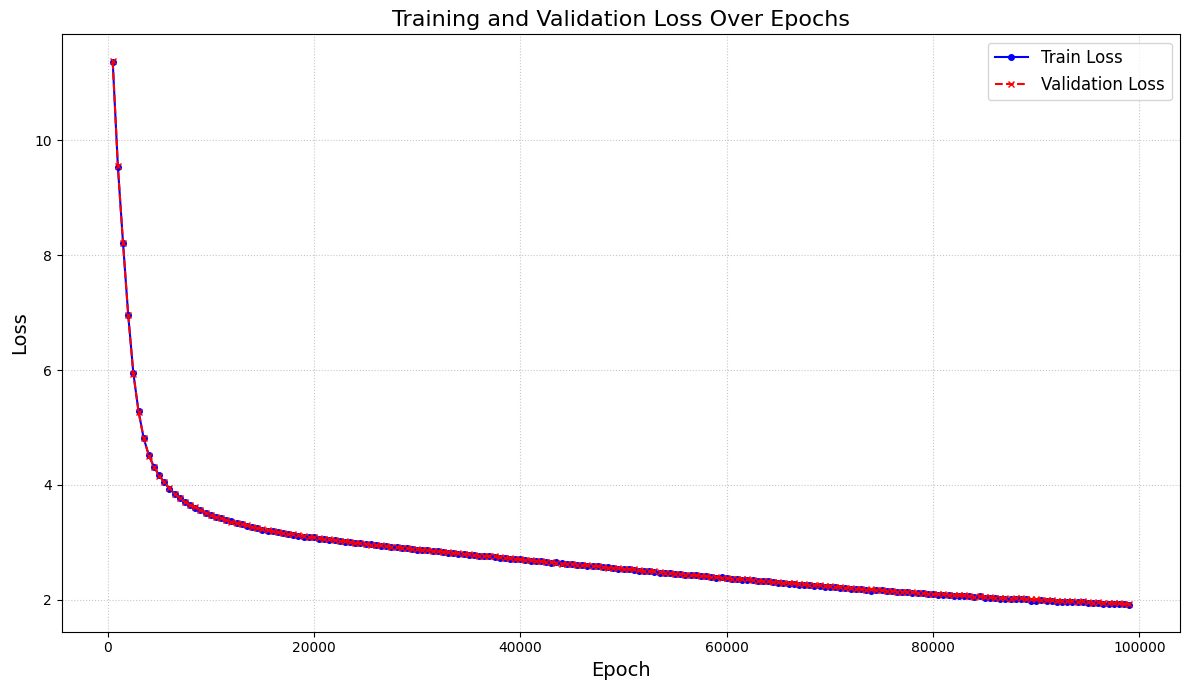

In [ ]:
import re
import matplotlib.pyplot as plt

log_data = """
Epoch 500: train loss 11.3635, val loss 11.3688
Current learning rate: 0.000067
✓ New best model saved! (val loss: 11.3688)

Epoch 1000: train loss 9.5379, val loss 9.5441
Current learning rate: 0.000100
✓ New best model saved! (val loss: 9.5441)

Epoch 1500: train loss 8.2078, val loss 8.2028
Current learning rate: 0.000100
✓ New best model saved! (val loss: 8.2028)

Epoch 2000: train loss 6.9601, val loss 6.9551
Current learning rate: 0.000100
✓ New best model saved! (val loss: 6.9551)

Epoch 2500: train loss 5.9443, val loss 5.9371
Current learning rate: 0.000100
✓ New best model saved! (val loss: 5.9371)

Epoch 3000: train loss 5.2834, val loss 5.2765
Current learning rate: 0.000100
✓ New best model saved! (val loss: 5.2765)

Epoch 3500: train loss 4.8141, val loss 4.8140
Current learning rate: 0.000100
✓ New best model saved! (val loss: 4.8140)

Epoch 4000: train loss 4.5156, val loss 4.5115
Current learning rate: 0.000100
✓ New best model saved! (val loss: 4.5115)

Epoch 4500: train loss 4.3145, val loss 4.3183
Current learning rate: 0.000101
✓ New best model saved! (val loss: 4.3183)

Epoch 5000: train loss 4.1693, val loss 4.1608
Current learning rate: 0.000101
✓ New best model saved! (val loss: 4.1608)

Epoch 5500: train loss 4.0458, val loss 4.0473
Current learning rate: 0.000101
✓ New best model saved! (val loss: 4.0473)

Epoch 6000: train loss 3.9382, val loss 3.9427
Current learning rate: 0.000101
✓ New best model saved! (val loss: 3.9427)

Epoch 6500: train loss 3.8492, val loss 3.8461
Current learning rate: 0.000101
✓ New best model saved! (val loss: 3.8461)

Epoch 7000: train loss 3.7718, val loss 3.7727
Current learning rate: 0.000102
✓ New best model saved! (val loss: 3.7727)

Epoch 7500: train loss 3.7080, val loss 3.7053
Current learning rate: 0.000102
✓ New best model saved! (val loss: 3.7053)

Epoch 8000: train loss 3.6534, val loss 3.6546
Current learning rate: 0.000102
✓ New best model saved! (val loss: 3.6546)

Epoch 8500: train loss 3.6063, val loss 3.6135
Current learning rate: 0.000102
✓ New best model saved! (val loss: 3.6135)

Epoch 9000: train loss 3.5599, val loss 3.5646
Current learning rate: 0.000103
✓ New best model saved! (val loss: 3.5646)

Epoch 9500: train loss 3.5178, val loss 3.5186
Current learning rate: 0.000103
✓ New best model saved! (val loss: 3.5186)

Epoch 10000: train loss 3.4816, val loss 3.4816
Current learning rate: 0.000104
✓ New best model saved! (val loss: 3.4816)

Epoch 10500: train loss 3.4482, val loss 3.4433
Current learning rate: 0.000104
✓ New best model saved! (val loss: 3.4433)

Epoch 11000: train loss 3.4235, val loss 3.4252
Current learning rate: 0.000104
✓ New best model saved! (val loss: 3.4252)

Epoch 11500: train loss 3.3890, val loss 3.3865
Current learning rate: 0.000105
✓ New best model saved! (val loss: 3.3865)

Epoch 12000: train loss 3.3669, val loss 3.3614
Current learning rate: 0.000105
✓ New best model saved! (val loss: 3.3614)

Epoch 12500: train loss 3.3380, val loss 3.3414
Current learning rate: 0.000106
✓ New best model saved! (val loss: 3.3414)

Epoch 13000: train loss 3.3124, val loss 3.3219
Current learning rate: 0.000106
✓ New best model saved! (val loss: 3.3219)

Epoch 13500: train loss 3.2887, val loss 3.2954
Current learning rate: 0.000107
✓ New best model saved! (val loss: 3.2954)

Epoch 14000: train loss 3.2688, val loss 3.2707
Current learning rate: 0.000107
✓ New best model saved! (val loss: 3.2707)

Epoch 14500: train loss 3.2518, val loss 3.2547
Current learning rate: 0.000108
✓ New best model saved! (val loss: 3.2547)

Epoch 15000: train loss 3.2243, val loss 3.2318
Current learning rate: 0.000109
✓ New best model saved! (val loss: 3.2318)

Epoch 15500: train loss 3.2063, val loss 3.2162
Current learning rate: 0.000109
✓ New best model saved! (val loss: 3.2162)

Epoch 16000: train loss 3.1987, val loss 3.1944
Current learning rate: 0.000110
✓ New best model saved! (val loss: 3.1944)

Epoch 16500: train loss 3.1768, val loss 3.1772
Current learning rate: 0.000111
✓ New best model saved! (val loss: 3.1772)

Epoch 17000: train loss 3.1682, val loss 3.1689
Current learning rate: 0.000111
✓ New best model saved! (val loss: 3.1689)

Epoch 17500: train loss 3.1482, val loss 3.1474
Current learning rate: 0.000112
✓ New best model saved! (val loss: 3.1474)

Epoch 18000: train loss 3.1372, val loss 3.1415
Current learning rate: 0.000113
✓ New best model saved! (val loss: 3.1415)

Epoch 18500: train loss 3.1195, val loss 3.1221
Current learning rate: 0.000113
✓ New best model saved! (val loss: 3.1221)

Epoch 19000: train loss 3.1030, val loss 3.1110
Current learning rate: 0.000114
✓ New best model saved! (val loss: 3.1110)

Epoch 19500: train loss 3.0933, val loss 3.0939
Current learning rate: 0.000115
✓ New best model saved! (val loss: 3.0939)

Epoch 20000: train loss 3.0881, val loss 3.0883
Current learning rate: 0.000116
✓ New best model saved! (val loss: 3.0883)

Epoch 20500: train loss 3.0681, val loss 3.0753
Current learning rate: 0.000117
✓ New best model saved! (val loss: 3.0753)

Epoch 21000: train loss 3.0613, val loss 3.0576
Current learning rate: 0.000118
✓ New best model saved! (val loss: 3.0576)

Epoch 21500: train loss 3.0477, val loss 3.0569
Current learning rate: 0.000118
✓ New best model saved! (val loss: 3.0569)

Epoch 22000: train loss 3.0401, val loss 3.0431
Current learning rate: 0.000119
✓ New best model saved! (val loss: 3.0431)

Epoch 22500: train loss 3.0319, val loss 3.0249
Current learning rate: 0.000120
✓ New best model saved! (val loss: 3.0249)

Epoch 23000: train loss 3.0070, val loss 3.0223
Current learning rate: 0.000121
✓ New best model saved! (val loss: 3.0223)

Epoch 23500: train loss 2.9991, val loss 3.0068
Current learning rate: 0.000122
✓ New best model saved! (val loss: 3.0068)

Epoch 24000: train loss 2.9988, val loss 2.9962
Current learning rate: 0.000123
✓ New best model saved! (val loss: 2.9962)

Epoch 24500: train loss 2.9941, val loss 2.9889
Current learning rate: 0.000124
✓ New best model saved! (val loss: 2.9889)

Epoch 25000: train loss 2.9715, val loss 2.9763
Current learning rate: 0.000125
✓ New best model saved! (val loss: 2.9763)

Epoch 25500: train loss 2.9658, val loss 2.9597
Current learning rate: 0.000126
✓ New best model saved! (val loss: 2.9597)

Epoch 26000: train loss 2.9562, val loss 2.9501
Current learning rate: 0.000127
✓ New best model saved! (val loss: 2.9501)

Epoch 26500: train loss 2.9437, val loss 2.9483
Current learning rate: 0.000128
✓ New best model saved! (val loss: 2.9483)

Epoch 27000: train loss 2.9353, val loss 2.9332
Current learning rate: 0.000129
✓ New best model saved! (val loss: 2.9332)

Epoch 27500: train loss 2.9292, val loss 2.9273
Current learning rate: 0.000130
✓ New best model saved! (val loss: 2.9273)

Epoch 28000: train loss 2.9271, val loss 2.9184
Current learning rate: 0.000132
✓ New best model saved! (val loss: 2.9184)

Epoch 28500: train loss 2.9066, val loss 2.9100
Current learning rate: 0.000133
✓ New best model saved! (val loss: 2.9100)

Epoch 29000: train loss 2.8966, val loss 2.9049
Current learning rate: 0.000134
✓ New best model saved! (val loss: 2.9049)

Epoch 29500: train loss 2.8891, val loss 2.8886
Current learning rate: 0.000135
✓ New best model saved! (val loss: 2.8886)

Epoch 30000: train loss 2.8704, val loss 2.8808
Current learning rate: 0.000136
✓ New best model saved! (val loss: 2.8808)

Epoch 30500: train loss 2.8708, val loss 2.8699
Current learning rate: 0.000137
✓ New best model saved! (val loss: 2.8699)

Epoch 31000: train loss 2.8622, val loss 2.8667
Current learning rate: 0.000139
✓ New best model saved! (val loss: 2.8667)

Epoch 31500: train loss 2.8578, val loss 2.8549
Current learning rate: 0.000140
✓ New best model saved! (val loss: 2.8549)

Epoch 32000: train loss 2.8468, val loss 2.8440
Current learning rate: 0.000141
✓ New best model saved! (val loss: 2.8440)

Epoch 32500: train loss 2.8374, val loss 2.8403
Current learning rate: 0.000143
✓ New best model saved! (val loss: 2.8403)

Epoch 33000: train loss 2.8247, val loss 2.8288
Current learning rate: 0.000144
✓ New best model saved! (val loss: 2.8288)

Epoch 33500: train loss 2.8207, val loss 2.8206
Current learning rate: 0.000145
✓ New best model saved! (val loss: 2.8206)

Epoch 34000: train loss 2.8065, val loss 2.8089
Current learning rate: 0.000146
✓ New best model saved! (val loss: 2.8089)

Epoch 34500: train loss 2.7975, val loss 2.7972
Current learning rate: 0.000148
✓ New best model saved! (val loss: 2.7972)

Epoch 35000: train loss 2.7884, val loss 2.7966
Current learning rate: 0.000149
✓ New best model saved! (val loss: 2.7966)

Epoch 35500: train loss 2.7774, val loss 2.7835
Current learning rate: 0.000151
✓ New best model saved! (val loss: 2.7835)

Epoch 36000: train loss 2.7646, val loss 2.7701
Current learning rate: 0.000152
✓ New best model saved! (val loss: 2.7701)

Epoch 36500: train loss 2.7685, val loss 2.7633
Current learning rate: 0.000153
✓ New best model saved! (val loss: 2.7633)

Epoch 37000: train loss 2.7591, val loss 2.7594
Current learning rate: 0.000155
✓ New best model saved! (val loss: 2.7594)

Epoch 37500: train loss 2.7449, val loss 2.7574
Current learning rate: 0.000156
✓ New best model saved! (val loss: 2.7574)

Epoch 38000: train loss 2.7378, val loss 2.7478
Current learning rate: 0.000158
✓ New best model saved! (val loss: 2.7478)

Epoch 38500: train loss 2.7315, val loss 2.7340
Current learning rate: 0.000159
✓ New best model saved! (val loss: 2.7340)

Epoch 39000: train loss 2.7203, val loss 2.7266
Current learning rate: 0.000161
✓ New best model saved! (val loss: 2.7266)

Epoch 39500: train loss 2.7164, val loss 2.7166
Current learning rate: 0.000162
✓ New best model saved! (val loss: 2.7166)

Epoch 40000: train loss 2.7094, val loss 2.7035
Current learning rate: 0.000164
✓ New best model saved! (val loss: 2.7035)

Epoch 40500: train loss 2.6930, val loss 2.6958
Current learning rate: 0.000165
✓ New best model saved! (val loss: 2.6958)

Epoch 41000: train loss 2.6819, val loss 2.6910
Current learning rate: 0.000167
✓ New best model saved! (val loss: 2.6910)

Epoch 41500: train loss 2.6798, val loss 2.6818
Current learning rate: 0.000169
✓ New best model saved! (val loss: 2.6818)

Epoch 42000: train loss 2.6710, val loss 2.6712
Current learning rate: 0.000170
✓ New best model saved! (val loss: 2.6712)

Epoch 42500: train loss 2.6601, val loss 2.6606
Current learning rate: 0.000172
✓ New best model saved! (val loss: 2.6606)

Epoch 43000: train loss 2.6498, val loss 2.6569
Current learning rate: 0.000173
✓ New best model saved! (val loss: 2.6569)

Epoch 43500: train loss 2.6538, val loss 2.6480
Current learning rate: 0.000175
✓ New best model saved! (val loss: 2.6480)

Epoch 44000: train loss 2.6346, val loss 2.6322
Current learning rate: 0.000177
✓ New best model saved! (val loss: 2.6322)

Epoch 44500: train loss 2.6295, val loss 2.6282
Current learning rate: 0.000178
✓ New best model saved! (val loss: 2.6282)

Epoch 45000: train loss 2.6220, val loss 2.6320
Current learning rate: 0.000180

Epoch 45500: train loss 2.6088, val loss 2.6153
Current learning rate: 0.000182
✓ New best model saved! (val loss: 2.6153)

Epoch 46000: train loss 2.6105, val loss 2.6078
Current learning rate: 0.000183
✓ New best model saved! (val loss: 2.6078)

Epoch 46500: train loss 2.5953, val loss 2.6019
Current learning rate: 0.000185
✓ New best model saved! (val loss: 2.6019)

Epoch 47000: train loss 2.5913, val loss 2.5930
Current learning rate: 0.000187
✓ New best model saved! (val loss: 2.5930)

Epoch 47500: train loss 2.5835, val loss 2.5881
Current learning rate: 0.000189
✓ New best model saved! (val loss: 2.5881)

Epoch 48000: train loss 2.5762, val loss 2.5700
Current learning rate: 0.000190
✓ New best model saved! (val loss: 2.5700)

Epoch 48500: train loss 2.5707, val loss 2.5619
Current learning rate: 0.000192
✓ New best model saved! (val loss: 2.5619)

Epoch 49000: train loss 2.5565, val loss 2.5638
Current learning rate: 0.000194

Epoch 49500: train loss 2.5458, val loss 2.5466
Current learning rate: 0.000196
✓ New best model saved! (val loss: 2.5466)

Epoch 50000: train loss 2.5364, val loss 2.5452
Current learning rate: 0.000198
✓ New best model saved! (val loss: 2.5452)

Epoch 50500: train loss 2.5302, val loss 2.5337
Current learning rate: 0.000199
✓ New best model saved! (val loss: 2.5337)

Epoch 51000: train loss 2.5261, val loss 2.5372
Current learning rate: 0.000201

Epoch 51500: train loss 2.5082, val loss 2.5143
Current learning rate: 0.000203
✓ New best model saved! (val loss: 2.5143)

Epoch 52000: train loss 2.5053, val loss 2.5028
Current learning rate: 0.000205
✓ New best model saved! (val loss: 2.5028)

Epoch 52500: train loss 2.4977, val loss 2.5027
Current learning rate: 0.000207
✓ New best model saved! (val loss: 2.5027)

Epoch 53000: train loss 2.4883, val loss 2.5007
Current learning rate: 0.000209
✓ New best model saved! (val loss: 2.5007)

Epoch 53500: train loss 2.4738, val loss 2.4798
Current learning rate: 0.000211
✓ New best model saved! (val loss: 2.4798)

Epoch 54000: train loss 2.4668, val loss 2.4768
Current learning rate: 0.000212
✓ New best model saved! (val loss: 2.4768)

Epoch 54500: train loss 2.4673, val loss 2.4704
Current learning rate: 0.000214
✓ New best model saved! (val loss: 2.4704)

Epoch 55000: train loss 2.4579, val loss 2.4585
Current learning rate: 0.000216
✓ New best model saved! (val loss: 2.4585)

Epoch 55500: train loss 2.4438, val loss 2.4535
Current learning rate: 0.000218
✓ New best model saved! (val loss: 2.4535)

Epoch 56000: train loss 2.4326, val loss 2.4404
Current learning rate: 0.000220
✓ New best model saved! (val loss: 2.4404)

Epoch 56500: train loss 2.4353, val loss 2.4405
Current learning rate: 0.000222

Epoch 57000: train loss 2.4276, val loss 2.4284
Current learning rate: 0.000224
✓ New best model saved! (val loss: 2.4284)

Epoch 57500: train loss 2.4135, val loss 2.4210
Current learning rate: 0.000226
✓ New best model saved! (val loss: 2.4210)

Epoch 58000: train loss 2.4109, val loss 2.4144
Current learning rate: 0.000228
✓ New best model saved! (val loss: 2.4144)

Epoch 58500: train loss 2.3983, val loss 2.3999
Current learning rate: 0.000230
✓ New best model saved! (val loss: 2.3999)

Epoch 59000: train loss 2.3880, val loss 2.3994
Current learning rate: 0.000232
✓ New best model saved! (val loss: 2.3994)

Epoch 59500: train loss 2.3903, val loss 2.3825
Current learning rate: 0.000234
✓ New best model saved! (val loss: 2.3825)

Epoch 60000: train loss 2.3769, val loss 2.3853
Current learning rate: 0.000236

Epoch 60500: train loss 2.3648, val loss 2.3699
Current learning rate: 0.000238
✓ New best model saved! (val loss: 2.3699)

Epoch 61000: train loss 2.3643, val loss 2.3684
Current learning rate: 0.000240
✓ New best model saved! (val loss: 2.3684)

Epoch 61500: train loss 2.3479, val loss 2.3667
Current learning rate: 0.000242
✓ New best model saved! (val loss: 2.3667)

Epoch 62000: train loss 2.3463, val loss 2.3568
Current learning rate: 0.000244
✓ New best model saved! (val loss: 2.3568)

Epoch 62500: train loss 2.3410, val loss 2.3421
Current learning rate: 0.000246
✓ New best model saved! (val loss: 2.3421)

Epoch 63000: train loss 2.3213, val loss 2.3355
Current learning rate: 0.000248
✓ New best model saved! (val loss: 2.3355)

Epoch 63500: train loss 2.3277, val loss 2.3268
Current learning rate: 0.000250
✓ New best model saved! (val loss: 2.3268)

Epoch 64000: train loss 2.3216, val loss 2.3222
Current learning rate: 0.000252
✓ New best model saved! (val loss: 2.3222)

Epoch 64500: train loss 2.3089, val loss 2.3103
Current learning rate: 0.000254
✓ New best model saved! (val loss: 2.3103)

Epoch 65000: train loss 2.3020, val loss 2.3044
Current learning rate: 0.000256
✓ New best model saved! (val loss: 2.3044)

Epoch 65500: train loss 2.2856, val loss 2.2977
Current learning rate: 0.000258
✓ New best model saved! (val loss: 2.2977)

Epoch 66000: train loss 2.2851, val loss 2.2922
Current learning rate: 0.000260
✓ New best model saved! (val loss: 2.2922)

Epoch 66500: train loss 2.2747, val loss 2.2887
Current learning rate: 0.000262
✓ New best model saved! (val loss: 2.2887)

Epoch 67000: train loss 2.2673, val loss 2.2746
Current learning rate: 0.000264
✓ New best model saved! (val loss: 2.2746)

Epoch 67500: train loss 2.2630, val loss 2.2720
Current learning rate: 0.000266
✓ New best model saved! (val loss: 2.2720)

Epoch 68000: train loss 2.2568, val loss 2.2625
Current learning rate: 0.000269
✓ New best model saved! (val loss: 2.2625)

Epoch 68500: train loss 2.2487, val loss 2.2553
Current learning rate: 0.000271
✓ New best model saved! (val loss: 2.2553)

Epoch 69000: train loss 2.2447, val loss 2.2559
Current learning rate: 0.000273

Epoch 69500: train loss 2.2327, val loss 2.2448
Current learning rate: 0.000275
✓ New best model saved! (val loss: 2.2448)

Epoch 70000: train loss 2.2327, val loss 2.2399
Current learning rate: 0.000277
✓ New best model saved! (val loss: 2.2399)

Epoch 70500: train loss 2.2171, val loss 2.2192
Current learning rate: 0.000279
✓ New best model saved! (val loss: 2.2192)

Epoch 71000: train loss 2.2120, val loss 2.2316
Current learning rate: 0.000281

Epoch 71500: train loss 2.2114, val loss 2.2131
Current learning rate: 0.000283
✓ New best model saved! (val loss: 2.2131)

Epoch 72000: train loss 2.1950, val loss 2.1987
Current learning rate: 0.000285
✓ New best model saved! (val loss: 2.1987)

Epoch 72500: train loss 2.1907, val loss 2.1961
Current learning rate: 0.000287
✓ New best model saved! (val loss: 2.1961)

Epoch 73000: train loss 2.1920, val loss 2.1973
Current learning rate: 0.000289

Epoch 73500: train loss 2.1791, val loss 2.1811
Current learning rate: 0.000292
✓ New best model saved! (val loss: 2.1811)

Epoch 74000: train loss 2.1636, val loss 2.1836
Current learning rate: 0.000294

Epoch 74500: train loss 2.1648, val loss 2.1725
Current learning rate: 0.000296
✓ New best model saved! (val loss: 2.1725)

Epoch 75000: train loss 2.1677, val loss 2.1657
Current learning rate: 0.000298
✓ New best model saved! (val loss: 2.1657)

Epoch 75500: train loss 2.1551, val loss 2.1625
Current learning rate: 0.000300
✓ New best model saved! (val loss: 2.1625)

Epoch 76000: train loss 2.1509, val loss 2.1633
Current learning rate: 0.000302

Epoch 76500: train loss 2.1448, val loss 2.1459
Current learning rate: 0.000304
✓ New best model saved! (val loss: 2.1459)

Epoch 77000: train loss 2.1372, val loss 2.1394
Current learning rate: 0.000306
✓ New best model saved! (val loss: 2.1394)

Epoch 77500: train loss 2.1298, val loss 2.1445
Current learning rate: 0.000308

Epoch 78000: train loss 2.1183, val loss 2.1355
Current learning rate: 0.000311
✓ New best model saved! (val loss: 2.1355)

Epoch 78500: train loss 2.1171, val loss 2.1239
Current learning rate: 0.000313
✓ New best model saved! (val loss: 2.1239)

Epoch 79000: train loss 2.1129, val loss 2.1219
Current learning rate: 0.000315
✓ New best model saved! (val loss: 2.1219)

Epoch 79500: train loss 2.1068, val loss 2.1080
Current learning rate: 0.000317
✓ New best model saved! (val loss: 2.1080)

Epoch 80000: train loss 2.0968, val loss 2.1012
Current learning rate: 0.000319
✓ New best model saved! (val loss: 2.1012)

Epoch 80500: train loss 2.0919, val loss 2.1024
Current learning rate: 0.000321

Epoch 81000: train loss 2.0938, val loss 2.0982
Current learning rate: 0.000323
✓ New best model saved! (val loss: 2.0982)

Epoch 81500: train loss 2.0840, val loss 2.0916
Current learning rate: 0.000325
✓ New best model saved! (val loss: 2.0916)

Epoch 82000: train loss 2.0694, val loss 2.0819
Current learning rate: 0.000327
✓ New best model saved! (val loss: 2.0819)

Epoch 82500: train loss 2.0690, val loss 2.0807
Current learning rate: 0.000329
✓ New best model saved! (val loss: 2.0807)

Epoch 83000: train loss 2.0648, val loss 2.0776
Current learning rate: 0.000331
✓ New best model saved! (val loss: 2.0776)

Epoch 83500: train loss 2.0623, val loss 2.0720
Current learning rate: 0.000334
✓ New best model saved! (val loss: 2.0720)

Epoch 84000: train loss 2.0489, val loss 2.0561
Current learning rate: 0.000336
✓ New best model saved! (val loss: 2.0561)

Epoch 84500: train loss 2.0618, val loss 2.0602
Current learning rate: 0.000338

Epoch 85000: train loss 2.0409, val loss 2.0515
Current learning rate: 0.000340
✓ New best model saved! (val loss: 2.0515)

Epoch 85500: train loss 2.0344, val loss 2.0447
Current learning rate: 0.000342
✓ New best model saved! (val loss: 2.0447)

Epoch 86000: train loss 2.0299, val loss 2.0395
Current learning rate: 0.000344
✓ New best model saved! (val loss: 2.0395)

Epoch 86500: train loss 2.0205, val loss 2.0358
Current learning rate: 0.000346
✓ New best model saved! (val loss: 2.0358)

Epoch 87000: train loss 2.0138, val loss 2.0279
Current learning rate: 0.000348
✓ New best model saved! (val loss: 2.0279)

Epoch 87500: train loss 2.0159, val loss 2.0238
Current learning rate: 0.000350
✓ New best model saved! (val loss: 2.0238)

Epoch 88000: train loss 2.0172, val loss 2.0257
Current learning rate: 0.000352

Epoch 88500: train loss 2.0085, val loss 2.0252
Current learning rate: 0.000354

Epoch 89000: train loss 2.0132, val loss 2.0213
Current learning rate: 0.000356
✓ New best model saved! (val loss: 2.0213)

Epoch 89500: train loss 1.9897, val loss 2.0079
Current learning rate: 0.000358
✓ New best model saved! (val loss: 2.0079)

Epoch 90000: train loss 1.9880, val loss 2.0073
Current learning rate: 0.000360
✓ New best model saved! (val loss: 2.0073)

Epoch 90500: train loss 1.9919, val loss 2.0026
Current learning rate: 0.000362
✓ New best model saved! (val loss: 2.0026)

Epoch 91000: train loss 1.9825, val loss 1.9970
Current learning rate: 0.000364
✓ New best model saved! (val loss: 1.9970)

Epoch 91500: train loss 1.9830, val loss 1.9903
Current learning rate: 0.000366
✓ New best model saved! (val loss: 1.9903)

Epoch 92000: train loss 1.9710, val loss 1.9883
Current learning rate: 0.000368
✓ New best model saved! (val loss: 1.9883)

Epoch 92500: train loss 1.9698, val loss 1.9775
Current learning rate: 0.000370
✓ New best model saved! (val loss: 1.9775)

Epoch 93000: train loss 1.9683, val loss 1.9748
Current learning rate: 0.000372
✓ New best model saved! (val loss: 1.9748)

Epoch 93500: train loss 1.9617, val loss 1.9769
Current learning rate: 0.000374

Epoch 94000: train loss 1.9567, val loss 1.9705
Current learning rate: 0.000376
✓ New best model saved! (val loss: 1.9705)

Epoch 94500: train loss 1.9580, val loss 1.9727
Current learning rate: 0.000378

Epoch 95000: train loss 1.9519, val loss 1.9644
Current learning rate: 0.000380
✓ New best model saved! (val loss: 1.9644)

Epoch 95500: train loss 1.9432, val loss 1.9548
Current learning rate: 0.000382
✓ New best model saved! (val loss: 1.9548)

Epoch 96000: train loss 1.9475, val loss 1.9581
Current learning rate: 0.000384

Epoch 96500: train loss 1.9375, val loss 1.9478
Current learning rate: 0.000386
✓ New best model saved! (val loss: 1.9478)

Epoch 97000: train loss 1.9243, val loss 1.9464
Current learning rate: 0.000388
✓ New best model saved! (val loss: 1.9464)

Epoch 97500: train loss 1.9365, val loss 1.9439
Current learning rate: 0.000389
✓ New best model saved! (val loss: 1.9439)

Epoch 98000: train loss 1.9338, val loss 1.9389
Current learning rate: 0.000391
✓ New best model saved! (val loss: 1.9389)

Epoch 98500: train loss 1.9288, val loss 1.9357
Current learning rate: 0.000393
✓ New best model saved! (val loss: 1.9357)

Epoch 99000: train loss 1.9190, val loss 1.9263
Current learning rate: 0.000395
✓ New best model saved! (val loss: 1.9263)
"""

epochs = []
train_losses = []
val_losses = []

# Regex to extract epoch, train loss, and val loss
pattern = r"Epoch (\d+): train loss (\d+\.\d+), val loss (\d+\.\d+)"

for line in log_data.split('\n'):
    match = re.search(pattern, line)
    if match:
        epochs.append(int(match.group(1)))
        train_losses.append(float(match.group(2)))
        val_losses.append(float(match.group(3)))

# Create the plot
plt.figure(figsize=(12, 7))
plt.plot(epochs, train_losses, label='Train Loss', color='blue', marker='o', markersize=4, linestyle='-')
plt.plot(epochs, val_losses, label='Validation Loss', color='red', marker='x', markersize=4, linestyle='--')

plt.title('Training and Validation Loss Over Epochs', fontsize=16)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

#LOAD BEST MODEL AND GENERATE TEXT

In [ ]:
# Load the best model checkpoint and generate text samples
# This demonstrates the model's text generation capabilities

# Re-create model with same configuration
model = Gemma3Model(GEMMA3_CONFIG)
device = "cuda" if torch.cuda.is_available() else "cpu"
best_model_params_path = "gemma3_model.pt"

# Load best model weights
print(f"\nLoading best model from: {best_model_params_path}")
model.load_state_dict(torch.load(best_model_params_path, map_location=torch.device(device)))
model = model.to(device)
model.eval()  # Set to evaluation mode
print("Model loaded successfully!")
print("=" * 70)

# Generate text samples
print("\nGenerating text samples...")
print("=" * 70)

# Sample 1: Classic story opening
sentence1 = "Once upon a time there was a little girl named Emma."
print(f"\nPrompt: {sentence1}")
context1 = torch.tensor(tokenizer.encode(sentence1, add_special_tokens=False)).unsqueeze(dim=0).to(device)
with torch.no_grad():
    y1 = model.generate(context1, max_new_tokens=200, temperature=0.8, top_k=50)
generated1 = tokenizer.decode(y1.squeeze().tolist(), skip_special_tokens=True)
print(f"Generated:\n{generated1}")
print("-" * 70)

# Sample 2: Adventure story
sentence2 = "A brave knight set out on a quest to find the magical treasure."
print(f"\nPrompt: {sentence2}")
context2 = torch.tensor(tokenizer.encode(sentence2, add_special_tokens=False)).unsqueeze(dim=0).to(device)
with torch.no_grad():
    y2 = model.generate(context2, max_new_tokens=200, temperature=0.8, top_k=50)
generated2 = tokenizer.decode(y2.squeeze().tolist(), skip_special_tokens=True)
print(f"Generated:\n{generated2}")
print("-" * 70)

# Sample 3: Animal story
sentence3 = "In a forest far away, a friendly bear met a curious rabbit."
print(f"\nPrompt: {sentence3}")
context3 = torch.tensor(tokenizer.encode(sentence3, add_special_tokens=False)).unsqueeze(dim=0).to(device)
with torch.no_grad():
    y3 = model.generate(context3, max_new_tokens=200, temperature=0.8, top_k=50)
generated3 = tokenizer.decode(y3.squeeze().tolist(), skip_special_tokens=True)
print(f"Generated:\n{generated3}")
print("=" * 70)
print("\nText generation complete!")


Loading best model from: gemma3_model.pt
Model loaded successfully!

Generating text samples...

Prompt: Once upon a time there was a little girl named Emma.
Generated:
Once upon a time there was a little girl named Emma. She was three years old and very excited to go to the beach.

So Sophie's parent was a beautiful little one. She was so excited and happy! She ran to the beach and shouted, "Please!"

But Lucy was not happy. She kept on her sand and ran around the beach. Suddenly, she heard a loud roar. She looked through the sky and saw a big, orange rock.

Lucy thought the rock was so beautiful. She stepped in and started to float. She felt so happy and excited!

The little girl reached the top of the rock and began to spin around. Everywhere it did, she felt like a beautiful bird!

When she was done, she stopped at the beach, she heard a voice. It said to her, "What's wrong, Mandy! You could be found!"

But the voice spoke. She was brave and said, "I'm sure, I'll always come back 